<a href="https://colab.research.google.com/github/ekyaaa/pengolahan-citra/blob/main/Week09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tugas Praktikum**
Modul 10 – Thresholding, Segmentasi Sederhana

### 1 & 2. Membuat colab Week09 dan import library

In [33]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

### 3. Buat Global Threshold (BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV), dengan threshold = 170, secara manual sesuai dengan deskripsi dari grafik yang ditunjukkan di atas.

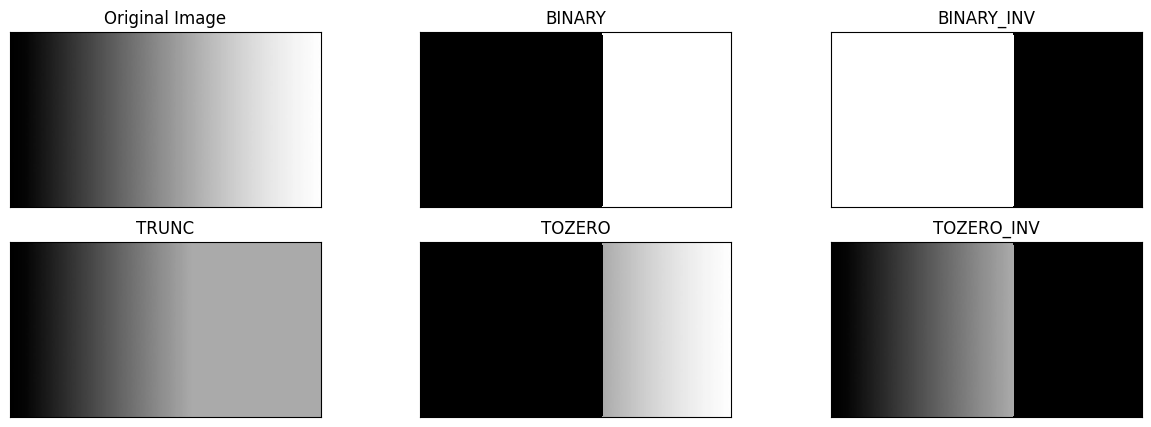

In [34]:
filename = ('/content/drive/MyDrive/pcvk_images/Images/gradient.jpg')

img = cv.imread(filename)

thresh = 170 #nilai Threshold yang ditentukan

#1. thresh1 jika pixel di img>127, maka thresh1 bernilai 1(putih) selain itu bernilai 0(hitam)
ret,thresh1 = cv.threshold(img,thresh,255,cv.THRESH_BINARY)
#2. thresh2 adalah binary threshold inverse
ret,thresh2 = cv.threshold(img,thresh,255,cv.THRESH_BINARY_INV)
#3. Threshold Truncate
ret,thresh3 = cv.threshold(img,thresh,255,cv.THRESH_TRUNC)
#4. Threshold Tozero
ret,thresh4 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO)
#5. Threshold Tozero Inverse
ret,thresh5 = cv.threshold(img,thresh,255,cv.THRESH_TOZERO_INV)

titles = ['Original Image','BINARY','BINARY_INV','TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize = (15,5))
for i in range(len(images)):
  plt.subplot(2,3,i+1),plt.imshow(images[i],'gray', interpolation='nearest')
  plt.title(titles[i])
  plt.xticks([]),plt.yticks([])

plt.show()

### 4. Buat Otsu Thresholding tanpa menggunakan Library
Tampilkan juga nilai threshold saat anda gunakan Otsu’s, seperti terlihat pada gambar hasil berikut. (gunakan image balloon.jpg agar terlihat beda antara hasil otsu’s dengan global threshold biasa)

In [35]:
# Fungsi Otsu
def otsu_threshold(image):
    # image: 2D list (rows × cols), values 0–255

    # 1. Hitung histogram (256 bin)
    hist = [0] * 256
    total_pixels = 0
    for row in image:
        for pixel in row:
            hist[pixel] += 1
            total_pixels += 1

    # 2. Hitung probabilitas tiap intensitas
    prob = [h / total_pixels for h in hist]

    # 3. Cari threshold terbaik
    max_variance = 0
    best_threshold = 0

    sum_total = sum(i * prob[i] for i in range(256))
    weight_b = 0
    mean_b = 0

    for t in range(256):
        weight_b += prob[t]
        if weight_b == 0:
            continue
        weight_f = 1 - weight_b
        if weight_f == 0:
            break

        mean_b += t * prob[t]
        mean_f = (sum_total - mean_b) / weight_f

        mean_b_current = mean_b / weight_b
        between_class_variance = weight_b * weight_f * (mean_b_current - mean_f) ** 2

        if between_class_variance > max_variance:
            max_variance = between_class_variance
            best_threshold = t

    return best_threshold

def apply_threshold(image, threshold):
    return [[255 if pixel > threshold else 0 for pixel in row] for row in image]


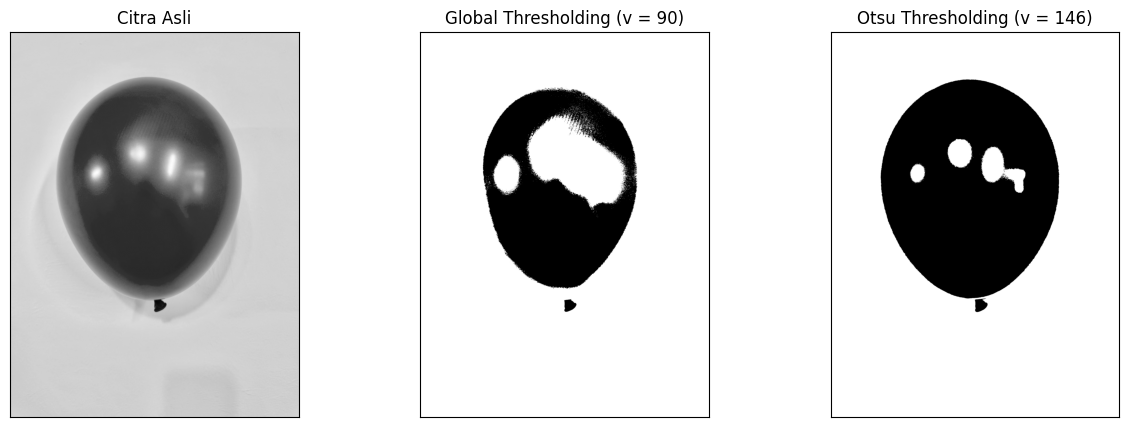

In [36]:
filename = '/content/drive/MyDrive/pcvk_images/balloon.jpg'
img = cv.imread(filename, cv.IMREAD_GRAYSCALE)

thresh = 90

ret, th1 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY)
th2 = apply_threshold(img, otsu_threshold(img))

titles = [
    'Citra Asli',
    'Global Thresholding (v = 90)',
    f"Otsu Thresholding (v = {otsu_threshold(img)})"
]
citra2 = [img, th1, th2]

plt.figure(figsize=(15, 5))

for i in range(len(citra2)):
    plt.subplot(1, len(citra2), i + 1)
    plt.imshow(citra2[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()


5. Buat histogram dari citra tersegmentasi, Histogram hanya pada foreground image saja. Gunakan image tobacco.jpg yang sudah disediakan di folder images.
Petunjuk:

*  Anda dapat gunakan cv.calcHist untuk menampilkan histogram.
*   Buka link berikut https://opencv-tutorial.readthedocs.io/en/latest/histogram/histogram.html
*   Dari link tersebut perhatikan bahwa cv.calcHist memiliki salah satu parameter yaitu mask. Jika diset None, maka keseluruhan image akan dihitung histogramnya Jika kita tentukan mask, maka hanya bagian image yang dimasking warna putih yang akan dihitung histogramnya (dari contoh dibawah dinamakan dengan Citra Segment).

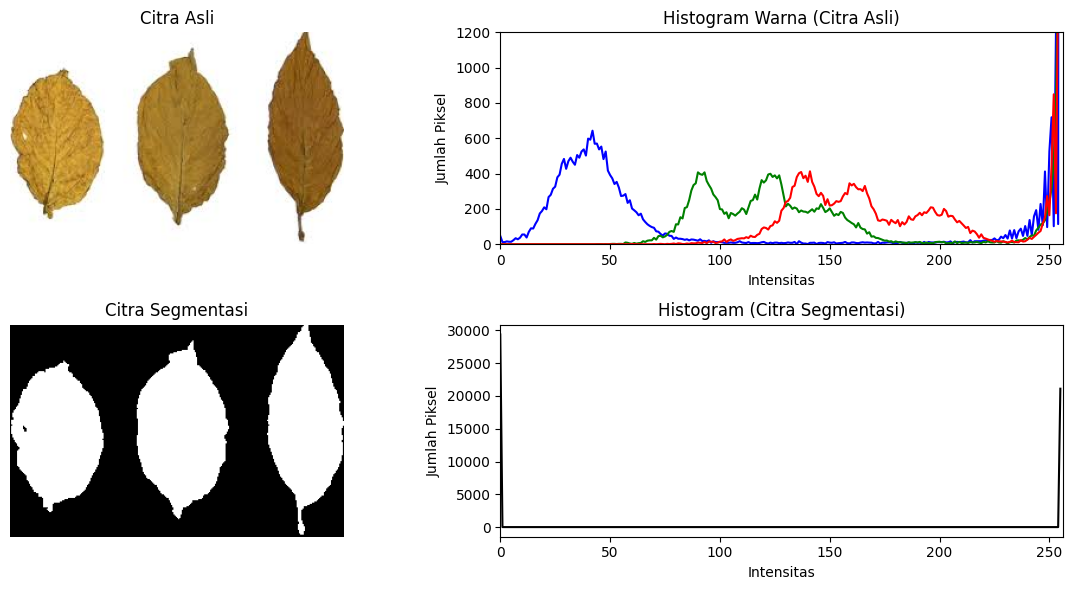

-1

In [37]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# --- Baca gambar ---
img = cv.imread('/content/drive/MyDrive/pcvk_images/tobacco.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# --- Segmentasi: ubah background putih jadi hitam, lainnya jadi putih ---
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
_, mask = cv.threshold(gray, 200, 255, cv.THRESH_BINARY)
segmented = cv.bitwise_not(mask)

# --- Hitung histogram untuk citra asli ---
chans = cv.split(img)
colors = ('b', 'g', 'r')
hists = []
for chan in chans:
    hists.append(cv.calcHist([chan], [0], None, [256], [0, 256]))

# --- Hitung histogram untuk citra segmentasi ---
hist_seg = cv.calcHist([segmented], [0], None, [256], [0, 256])

# --- Plotting layout ---
plt.figure(figsize=(12, 6))

# ========== KIRI: CITRA ==========
plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(segmented, cmap='gray')
plt.title('Citra Segmentasi')
plt.axis('off')

# ========== KANAN: HISTOGRAM ==========
plt.subplot(2, 2, 2)
for hist, color in zip(hists, colors):
    plt.plot(hist, color=color)
plt.title('Histogram Warna (Citra Asli)')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 256])
plt.ylim([0, 1200])

plt.subplot(2, 2, 4)
plt.plot(hist_seg, color='black')
plt.title('Histogram (Citra Segmentasi)')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Piksel')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()
cv.waitKey(0)


### 6. Lakukan segmentasi warna pada image "peppers.jpg", munculkan hanya warna yang kuning saja.
(Petunjuk: anda dapat gunakan K-Means untuk menampilkan hanya warna tertentu saja)

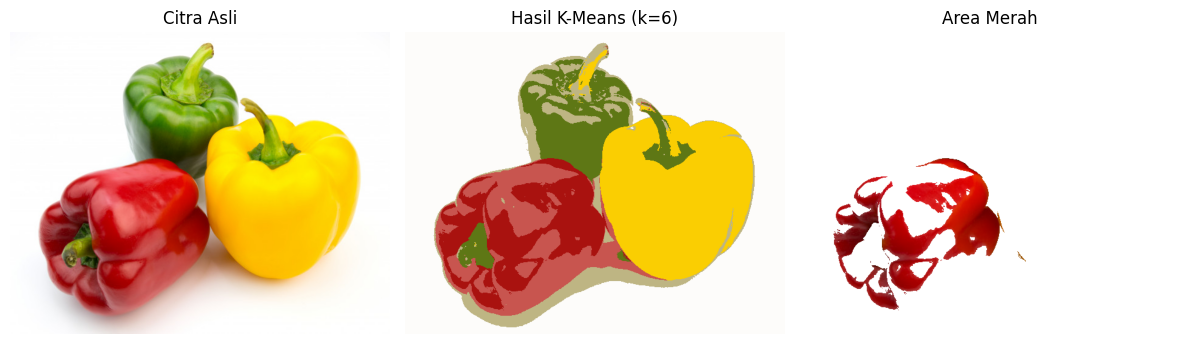

In [58]:
import cv2 as cv
import numpy as np
from matplotlib import pyplot as plt

# --- Baca gambar ---
img = cv.imread('/content/drive/MyDrive/pcvk_images/Images/peppers.jpg')
if img is None:
    raise FileNotFoundError("File peppers.jpg tidak ditemukan. Periksa path-nya.")

# Konversi ke RGB
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# --- Ubah ke array 2D ---
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# --- Tentukan k ---
k = 6
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
cv.setRNGSeed(42)  # agar hasil konsisten setiap run
_, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_PP_CENTERS)

# --- Kembalikan ke uint8 ---
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape(img_rgb.shape)

# --- Cari klaster dengan dominan merah ---
dominant_red_indices = [i for i, c in enumerate(centers) if (c[0] > 1.2*c[1] and c[0] > 1.2*c[2])]

if not dominant_red_indices:
    target_color = np.array([255, 0, 0])
    distances = np.linalg.norm(centers - target_color, axis=1)
    red_cluster_idx = np.argmin(distances)
else:
    red_strength = [centers[i][0] - (centers[i][1] + centers[i][2]) / 2 for i in dominant_red_indices]
    red_cluster_idx = dominant_red_indices[np.argmax(red_strength)]

# --- Buat mask untuk klaster merah ---
mask = (labels.flatten() == red_cluster_idx)
mask_2d = mask.reshape(img_rgb.shape[:2])

# --- Tampilkan hanya area merah dari gambar asli, lainnya putih ---
red_only_original = np.ones_like(img_rgb) * 255
red_only_original[mask_2d] = img_rgb[mask_2d]

# --- Visualisasi ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(segmented_image)
plt.title(f'Hasil K-Means (k={k})')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(red_only_original)
plt.title('Area Merah')
plt.axis('off')

plt.tight_layout()
plt.show()


#### Saat anda menampilkan warna tertentu, jelaskan kendala yang di hadapi dan mengapa hal itu terjadi.

warna yang dipilih hanya merah dan setiap run hasilnya berbeda karena centroidnya dipilih secara acak saat pertama kali.

### 7. Buka File crossword.jpg. Dengan pengetahuan tentang thresholding yang sudah anda pelajari. Lakukan thresholding biner dengan hasil terbaik menurut anda. Copas code dan hasil image di modul ini.

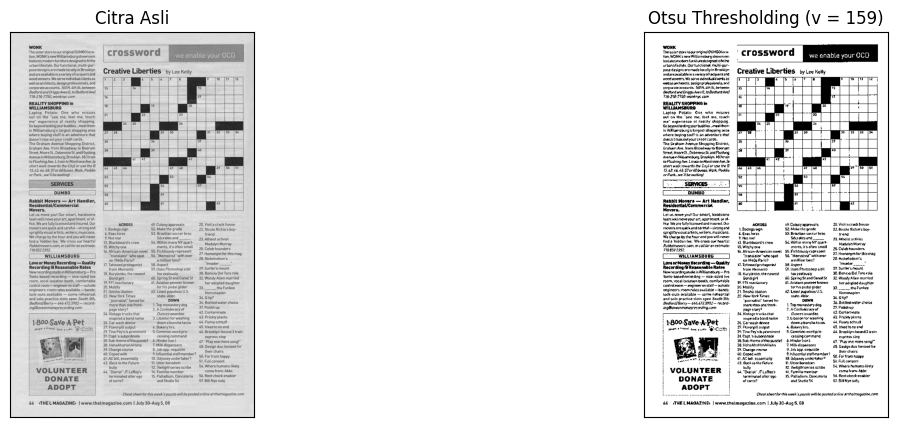

In [60]:
filename = '/content/drive/MyDrive/pcvk_images/Images/crossword.jpg'
img = cv.imread(filename, cv.IMREAD_GRAYSCALE)

thresh = 90

ret, th1 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY)
th2 = apply_threshold(img, otsu_threshold(img))

titles = [
    'Citra Asli',
    f"Otsu Thresholding (v = {otsu_threshold(img)})"
]
citra2 = [img, th2]

plt.figure(figsize=(15, 5))

for i in range(len(citra2)):
    plt.subplot(1, len(citra2), i + 1)
    plt.imshow(citra2[i], 'gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.show()
